In [19]:
import numpy as np
import pymc as pm
import arviz as az
import arviz_plots as azp
import matplotlib.pyplot as plt

In [2]:
np.random.seed(1)

#### Variational Inference (VI)

In [3]:
# Simulating linear regression data.

n = 100

x = np.random.normal(0, 1, n)

true_intercept = 1.5
true_slope = 2.0
true_sigma = 1.0

y = (
    true_intercept
    + true_slope * x
    + np.random.normal(0, true_sigma, n)
)

print("Sample size:", n)

Sample size: 100


In [4]:
# Building the Bayesian linear regression model.

with pm.Model() as vi_model:

    intercept = pm.Normal(
        "intercept",
        mu=0,
        sigma=10
    )

    slope = pm.Normal(
        "slope",
        mu=0,
        sigma=10
    )

    sigma = pm.HalfNormal(
        "sigma",
        sigma=5
    )

    mu = intercept + slope * x

    outcome = pm.Normal(
        "outcome",
        mu=mu,
        sigma=sigma,
        observed=y
    )

In [5]:
# Fitting the model using Variational Inference.

with vi_model:

    approx = pm.fit(
        n=20000,
        method="advi",
        random_seed=42
    )

Output()

Finished [100%]: Average Loss = 147.41


In [6]:
# Drawing posterior samples from the approximation.

with vi_model:

    vi_trace = approx.sample(2000)

In [8]:
# Posterior summary.

summary = az.summary(
    vi_trace,
    ci_prob=0.95
)

print(summary)

            mean     sd eti95_lb eti95_ub ess_bulk ess_tail r_hat mcse_mean mcse_sd
intercept   1.65  0.109      1.4      1.9     1785     1974   nan    0.0026  0.0018
slope      2.099  0.125      1.9      2.3     1999     1888   nan    0.0028   0.002
sigma      0.957  0.079     0.81      1.1     1831     1705   nan    0.0018  0.0013


#### Compare Variational Inference (VI) and MCMC

In [9]:
# Fitting the model using MCMC (NUTS).

with vi_model:

    mcmc_trace = pm.sample(
        draws=2000,
        tune=1000,
        random_seed=42,
        return_inferencedata=True
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, slope, sigma]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 3 seconds.


In [11]:
# Summarizing posterior estimates.

vi_summary = az.summary(
    vi_trace,
    kind="stats",
    ci_prob=0.95
)

mcmc_summary = az.summary(
    mcmc_trace,
    ci_prob=0.95
)

print("Variational Inference:\n", vi_summary)

print("\nMCMC:\n", mcmc_summary)

Variational Inference:
            mean     sd eti95_lb eti95_ub
intercept   1.6   0.11      1.4      1.9
slope       2.1   0.12      1.9      2.3
sigma      0.96  0.079     0.81      1.1

MCMC:
             mean     sd eti95_lb eti95_ub ess_bulk ess_tail r_hat mcse_mean  mcse_sd
intercept  1.647  0.096      1.5      1.8    11246     6189  1.00   0.00091  0.00065
slope      2.095  0.106      1.9      2.3    11746     6083  1.00   0.00098  0.00069
sigma      0.949   0.07     0.82      1.1    10159     6115  1.00    0.0007  0.00053


In [12]:
# Comparing parameter estimates.

parameters = ["intercept", "slope", "sigma"]

for parameter in parameters:

    vi_mean = vi_summary.loc[parameter, "mean"]
    mcmc_mean = mcmc_summary.loc[parameter, "mean"]

    print(parameter)
    print("VI mean:", round(vi_mean, 3))
    print("MCMC mean:", round(mcmc_mean, 3))
    print("Difference:", round(abs(vi_mean - mcmc_mean), 3))
    print()

intercept
VI mean: 1.65
MCMC mean: 1.647
Difference: 0.003

slope
VI mean: 2.099
MCMC mean: 2.095
Difference: 0.003

sigma
VI mean: 0.957
MCMC mean: 0.949
Difference: 0.008



Variational Inference


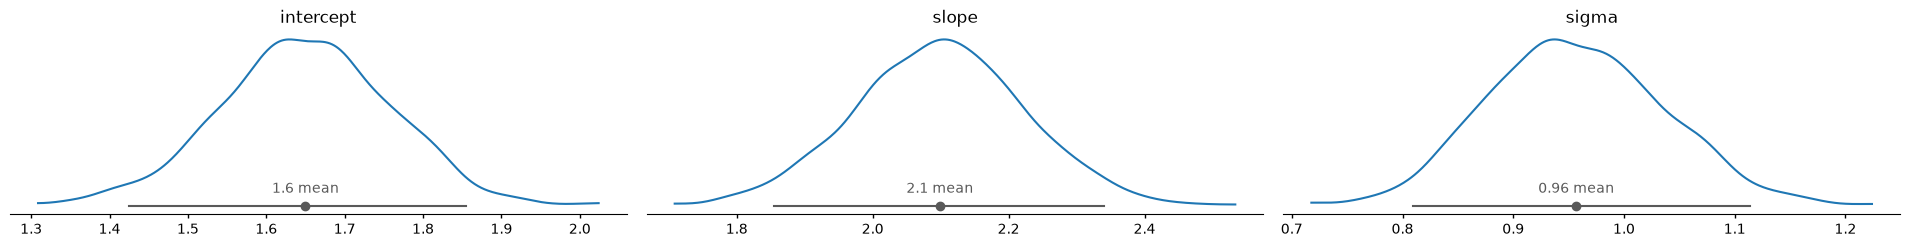


MCMC


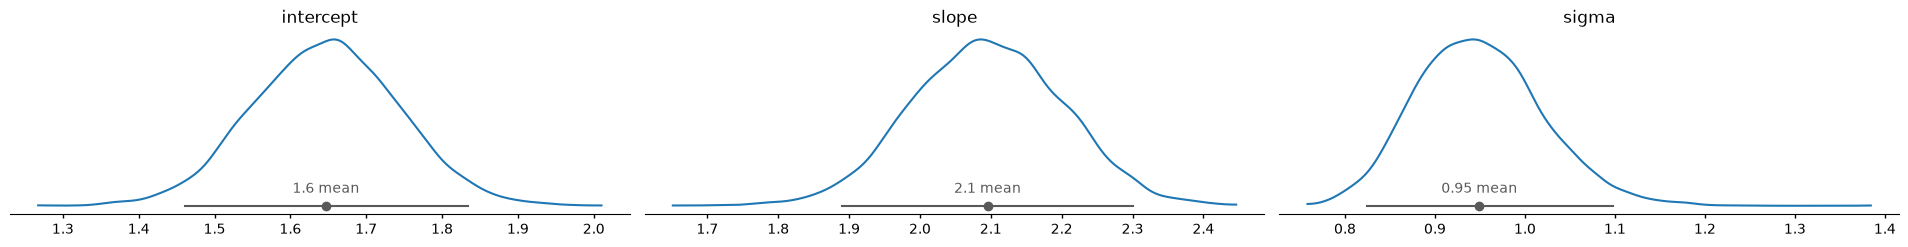

In [20]:
# Visualizing posterior distributions.

parameters = ["intercept", "slope", "sigma"]

print("Variational Inference")
azp.plot_dist(
    vi_trace,
    var_names=parameters,
    ci_prob=0.95
)

plt.tight_layout()
plt.show()

print("\nMCMC")
azp.plot_dist(
    mcmc_trace,
    var_names=parameters,
    ci_prob=0.95
)

plt.tight_layout()
plt.show()

Advantages of Variational Inference
- Much faster than MCMC.
- Scales well to large datasets.
- Useful when rapid approximate inference is needed.
- Suitable for complex models where MCMC is computationally expensive.

Limitations of Variational Inference
- Produces an approximate posterior.
- Often underestimates posterior uncertainty.
- May fail to capture correlations between parameters.
- Accuracy depends on the chosen variational family.

Advantages of MCMC
- Produces samples from the true posterior distribution.
- More accurate uncertainty estimates.
- Better suited for complex posterior distributions.

Limitations of MCMC
- Computationally expensive.
- Can require long sampling times.
- Requires convergence diagnostics (R-hat, ESS, trace plots).